In [11]:
from matplotlib import pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import scale, MinMaxScaler
from sklearn import svm
from sklearn.model_selection import train_test_split
from sklearn.multiclass import OneVsOneClassifier, OneVsRestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

## 1.1 Load and prepare the data set

In [12]:
penguins_df = sns.load_dataset('penguins')
# penguins_df = penguins_df[penguins_df['species'] != 'Adelie']

In [13]:
# Filter penguins to include species, bill_length_mm, bill_depth_mm
penguins_filtered_df = penguins_df[['species', 'bill_length_mm', 'bill_depth_mm']]
# remove NaN
penguins_filtered_df = penguins_filtered_df.dropna()
# exclude species = Chinstrap
subset_df = penguins_filtered_df[penguins_filtered_df['species'] != 'Chinstrap']

subset_df

,species,bill_length_mm,bill_depth_mm
0,Adelie,39.1,18.7
1,Adelie,39.5,17.4
2,Adelie,40.3,18.0
4,Adelie,36.7,19.3
5,Adelie,39.3,20.6
...,...,...,...
338,Gentoo,47.2,13.7
340,Gentoo,46.8,14.3
341,Gentoo,50.4,15.7
342,Gentoo,45.2,14.8


<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

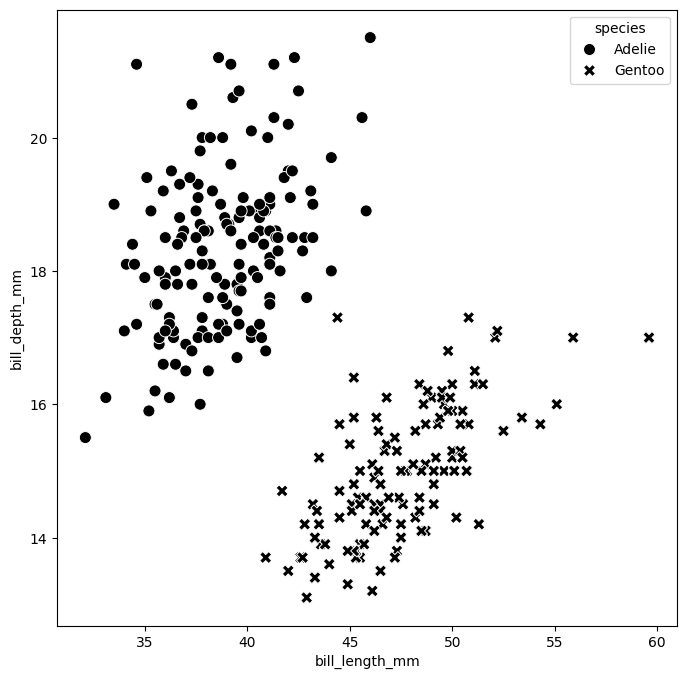

In [14]:
# Plot data
fig = plt.figure(figsize=(8,8))

sns.scatterplot(data=subset_df, x='bill_length_mm', y='bill_depth_mm', color='black', style='species', s=75)

## 1.2 Two-class Linear SVM

### Standardization:
Mean removal:

In [15]:
scaled_samples = scale(subset_df[['bill_length_mm', 'bill_depth_mm']])
subset_mean = subset_df.copy()
subset_mean[['bill_length_mm', 'bill_depth_mm']] = scaled_samples

subset_mean

,species,bill_length_mm,bill_depth_mm
0,Adelie,-0.694729,0.927421
1,Adelie,-0.617600,0.280569
2,Adelie,-0.463341,0.579116
4,Adelie,-1.157507,1.225969
5,Adelie,-0.656165,1.872821
...,...,...,...
338,Gentoo,0.867145,-1.560472
340,Gentoo,0.790015,-1.261925
341,Gentoo,1.484182,-0.565315
342,Gentoo,0.481497,-1.013136


<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

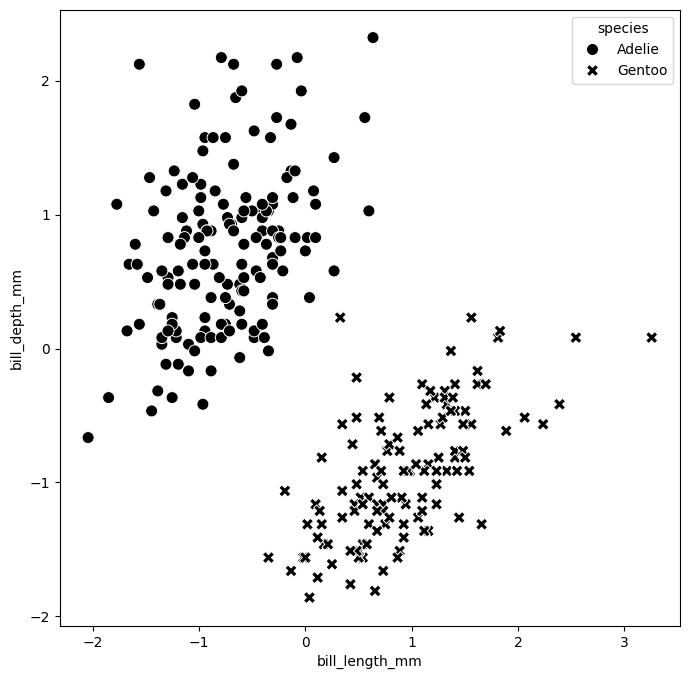

In [16]:
# Plot data
fig = plt.figure(figsize=(8,8))

sns.scatterplot(data=subset_mean, x='bill_length_mm', y='bill_depth_mm', color='black', style='species', s=75)

Normalization:

In [17]:
# Normalize numeric values
scaler = MinMaxScaler()
scaler.fit(subset_mean[['bill_length_mm', 'bill_depth_mm']])
scaled_samples = scaler.transform(subset_mean[['bill_length_mm', 'bill_depth_mm']])

#merge with species
subset_normalized = subset_mean.copy()
subset_normalized[['bill_length_mm', 'bill_depth_mm']] = scaled_samples

subset_normalized

,species,bill_length_mm,bill_depth_mm
0,Adelie,0.254545,0.666667
1,Adelie,0.269091,0.511905
2,Adelie,0.298182,0.583333
4,Adelie,0.167273,0.738095
5,Adelie,0.261818,0.892857
...,...,...,...
338,Gentoo,0.549091,0.071429
340,Gentoo,0.534545,0.142857
341,Gentoo,0.665455,0.309524
342,Gentoo,0.476364,0.202381


<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

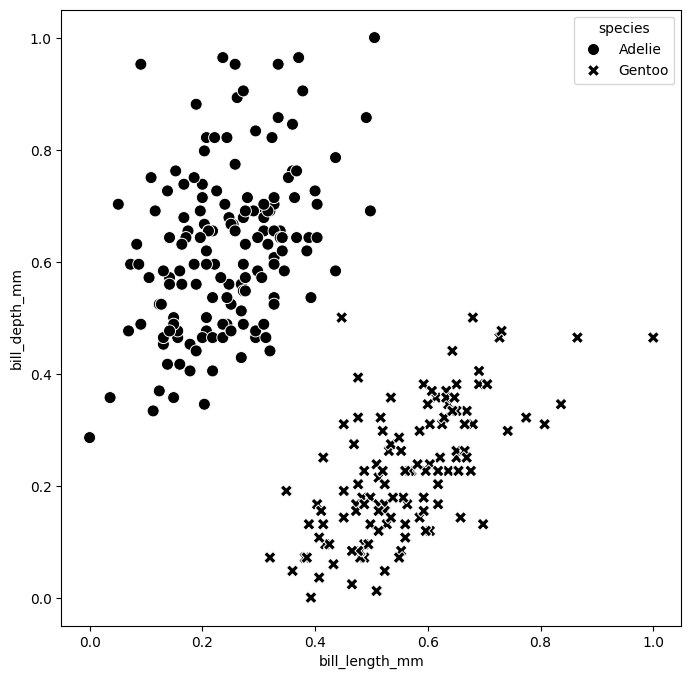

In [18]:
# Plot data
fig = plt.figure(figsize=(8,8))

sns.scatterplot(data=subset_normalized, x='bill_length_mm', y='bill_depth_mm', color='black', style='species', s=75)

In [19]:
# add numeric class for species. Used for training
subset_normalized['class'] = 0
subset_normalized.loc[subset_normalized['species'] == 'Adelie', 'class'] = 1 

subset_normalized

,species,bill_length_mm,bill_depth_mm,class
0,Adelie,0.254545,0.666667,1
1,Adelie,0.269091,0.511905,1
2,Adelie,0.298182,0.583333,1
4,Adelie,0.167273,0.738095,1
5,Adelie,0.261818,0.892857,1
...,...,...,...,...
338,Gentoo,0.549091,0.071429,0
340,Gentoo,0.534545,0.142857,0
341,Gentoo,0.665455,0.309524,0
342,Gentoo,0.476364,0.202381,0


Classification:

c:\Users\chris\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

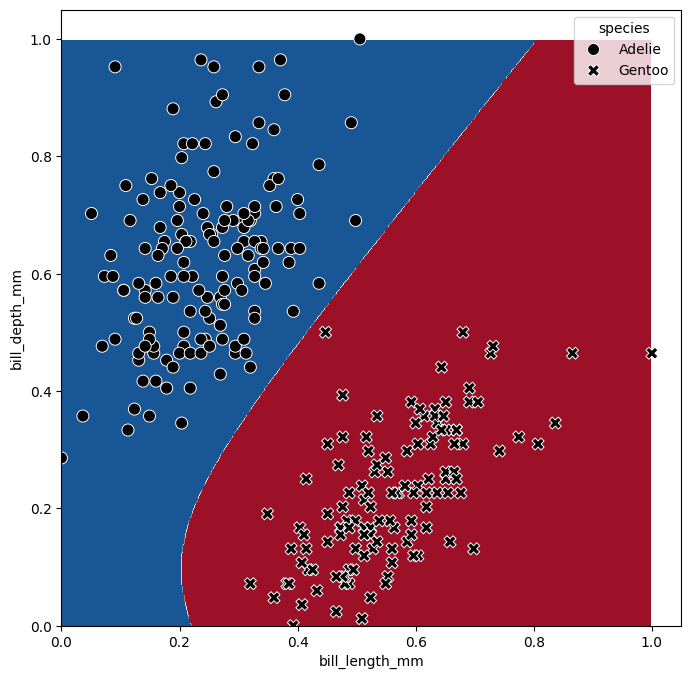

In [20]:
# Train
selected_kernel = 'poly'
classifier = svm.SVC(kernel=selected_kernel)
classifier.fit(subset_normalized[['bill_length_mm', 'bill_depth_mm']], subset_normalized['class'])



# Plot 
fig = plt.figure(figsize=(8, 8))
plot_step=0.002
xx, yy = np.meshgrid(np.arange(min(subset_normalized['bill_length_mm']), max(subset_normalized['bill_length_mm']), plot_step),
                     np.arange(min(subset_normalized['bill_depth_mm']), max(subset_normalized['bill_depth_mm']), plot_step))

plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
zz = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
zz = zz.reshape(xx.shape)
cs = plt.contourf(xx, yy, zz, cmap=plt.cm.RdBu)

sns.scatterplot(data=subset_normalized, x='bill_length_mm', y='bill_depth_mm', color='black', style='species', s=75)

## 1.3 Evaluating the Model

In [33]:
# Split
features = subset_normalized[['bill_length_mm', 'bill_depth_mm']]
classes = subset_normalized['class']

features_train, features_test, classes_train, classes_test = train_test_split(features, classes, test_size=0.2)

In [36]:
# Train Classifier
selected_kernel = 'linear'
classifier = svm.SVC(kernel=selected_kernel)
classifier.fit(features_train, classes_train)

# Predict test data
classes_predicted = classifier.predict(features_test)

# Calculate accuracy
accuracy = accuracy_score(classes_test, classes_predicted)
print(f'Accuracy: {accuracy}')

Accuracy: 0.9420289855072463


## 1.4 Non-linear Data

       species  bill_length_mm  bill_depth_mm
0       Adelie            39.1           18.7
1       Adelie            39.5           17.4
2       Adelie            40.3           18.0
4       Adelie            36.7           19.3
5       Adelie            39.3           20.6
..         ...             ...            ...
215  Chinstrap            55.8           19.8
216  Chinstrap            43.5           18.1
217  Chinstrap            49.6           18.2
218  Chinstrap            50.8           19.0
219  Chinstrap            50.2           18.7

[219 rows x 3 columns]


<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

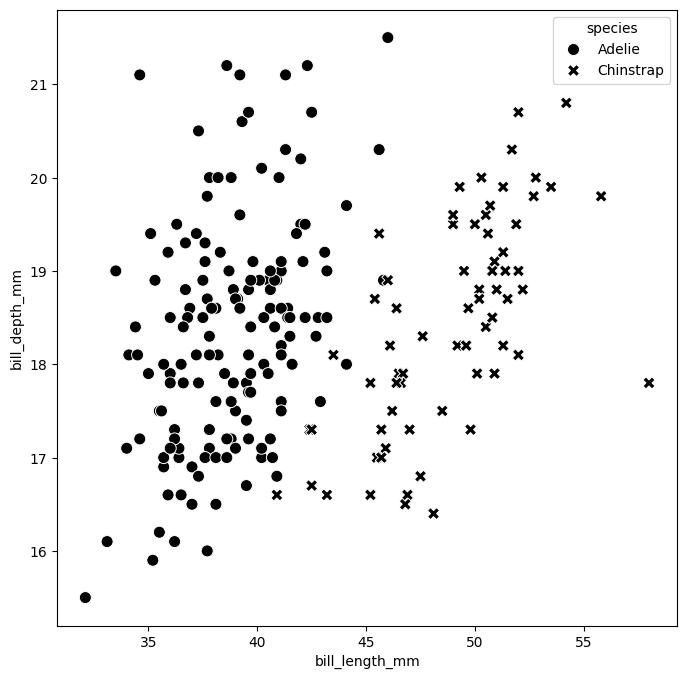

In [37]:
# New Dataset
subset = penguins_filtered_df[penguins_filtered_df['species'] != 'Gentoo']
print(subset)

fig = plt.figure(figsize=(8,8))
sns.scatterplot(data=subset, x='bill_length_mm', y='bill_depth_mm', color='black', style='species', s=75)

In [38]:
# mean removal
scaled_samples = scale(subset[['bill_length_mm', 'bill_depth_mm']])
subset_mean = subset.copy()
subset_mean[['bill_length_mm', 'bill_depth_mm']] = scaled_samples
# normalization
scaler = MinMaxScaler()
scaler.fit(subset_mean[['bill_length_mm', 'bill_depth_mm']])
scaled_samples = scaler.transform(subset_mean[['bill_length_mm', 'bill_depth_mm']])
subset_normalized = subset_mean.copy()
subset_normalized[['bill_length_mm', 'bill_depth_mm']] = scaled_samples
subset_normalized

# add numeric class for species
subset_normalized['class'] = 0
subset_normalized.loc[subset['species'] == 'Adelie', 'class'] = 1 

subset_normalized

,species,bill_length_mm,bill_depth_mm,class
0,Adelie,0.270270,0.533333,1
1,Adelie,0.285714,0.316667,1
2,Adelie,0.316602,0.416667,1
4,Adelie,0.177606,0.633333,1
5,Adelie,0.277992,0.850000,1
...,...,...,...,...
215,Chinstrap,0.915058,0.716667,0
216,Chinstrap,0.440154,0.433333,0
217,Chinstrap,0.675676,0.450000,0
218,Chinstrap,0.722008,0.583333,0


In [39]:
# Split
features = subset_normalized[['bill_length_mm', 'bill_depth_mm']]
classes = subset_normalized['class']

features_train, features_test, classes_train, classes_test = train_test_split(features, classes, random_state=10, test_size=0.2)

Accuracy: 0.9090909090909091


c:\Users\chris\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

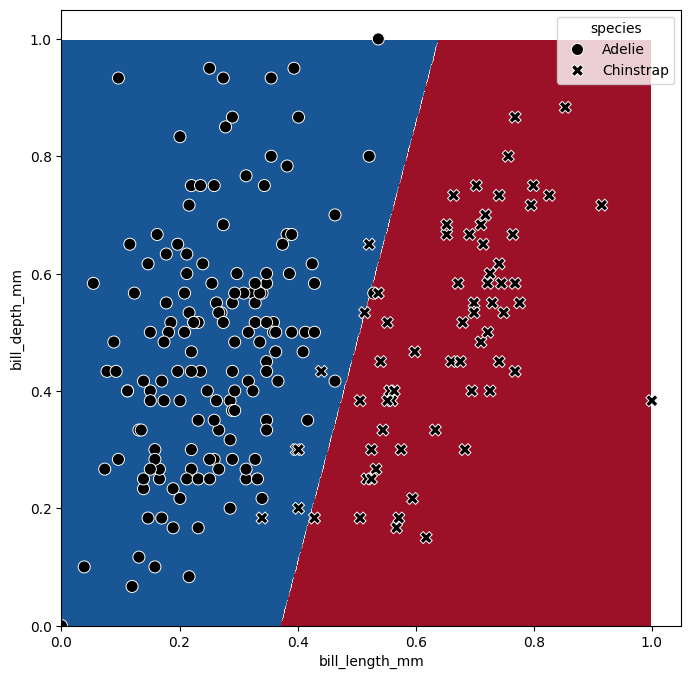

In [41]:
selected_kernel = 'linear'

# Train Classifier
classifier = svm.SVC(kernel=selected_kernel)
classifier.fit(features_train, classes_train)

# Predict test data
classes_predicted = classifier.predict(features_test)

# Calculate accuracy
accuracy = accuracy_score(classes_test, classes_predicted)
print(f'Accuracy: {accuracy}')

# Use complete data for decision boundaries 
classifier.fit(subset_normalized[['bill_length_mm', 'bill_depth_mm']], subset_normalized['class'])

# Plot 
fig = plt.figure(figsize=(8, 8))
plot_step=0.002
xx, yy = np.meshgrid(np.arange(min(subset_normalized['bill_length_mm']), max(subset_normalized['bill_length_mm']), plot_step),
                     np.arange(min(subset_normalized['bill_depth_mm']), max(subset_normalized['bill_depth_mm']), plot_step))

plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
zz = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
zz = zz.reshape(xx.shape)
cs = plt.contourf(xx, yy, zz, cmap=plt.cm.RdBu)

sns.scatterplot(data=subset_normalized, x='bill_length_mm', y='bill_depth_mm', color='black', style='species', s=75)


## 1.5 Multiclass SVM

In [42]:
subset = penguins_filtered_df.copy()
subset

,species,bill_length_mm,bill_depth_mm
0,Adelie,39.1,18.7
1,Adelie,39.5,17.4
2,Adelie,40.3,18.0
4,Adelie,36.7,19.3
5,Adelie,39.3,20.6
...,...,...,...
338,Gentoo,47.2,13.7
340,Gentoo,46.8,14.3
341,Gentoo,50.4,15.7
342,Gentoo,45.2,14.8


In [43]:
subset['species'].unique()

array(['Adelie', 'Chinstrap', 'Gentoo'], dtype=object)

In [44]:
# Standardization
# mean removal
scaled_samples = scale(subset[['bill_length_mm', 'bill_depth_mm']])
subset_mean = subset.copy()
subset_mean[['bill_length_mm', 'bill_depth_mm']] = scaled_samples

# normalization
scaler = MinMaxScaler()
scaler.fit(subset_mean[['bill_length_mm', 'bill_depth_mm']])
scaled_samples = scaler.transform(subset_mean[['bill_length_mm', 'bill_depth_mm']])
subset_normalized = subset_mean.copy()
subset_normalized[['bill_length_mm', 'bill_depth_mm']] = scaled_samples
subset_normalized

# add numeric class for species
subset_normalized['class'] = 0
subset_normalized.loc[subset['species'] == 'Chinstrap', 'class'] = 1
subset_normalized.loc[subset['species'] == 'Gentoo', 'class'] = 2

subset_normalized

,species,bill_length_mm,bill_depth_mm,class
0,Adelie,0.254545,0.666667,0
1,Adelie,0.269091,0.511905,0
2,Adelie,0.298182,0.583333,0
4,Adelie,0.167273,0.738095,0
5,Adelie,0.261818,0.892857,0
...,...,...,...,...
338,Gentoo,0.549091,0.071429,2
340,Gentoo,0.534545,0.142857,2
341,Gentoo,0.665455,0.309524,2
342,Gentoo,0.476364,0.202381,2


In [45]:
# Split
features = subset_normalized[['bill_length_mm', 'bill_depth_mm']]
classes = subset_normalized[['class']]

features_train, features_test, classes_train, classes_test = train_test_split(features, classes, test_size=0.2)

Accuracy 0.927536231884058


c:\Users\chris\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\chris\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

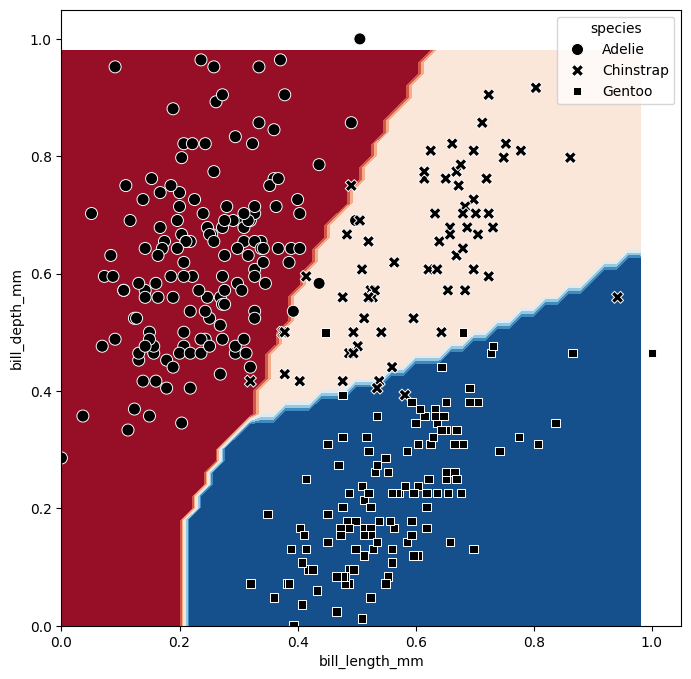

In [47]:
# training
selected_kernel = 'poly'

# train Classifier

# try different versions of the classifier
classifier = svm.SVC(kernel=selected_kernel) #OneVsOne by default
#classifier = OneVsOneClassifier(svm.SVC(kernel=selected_kernel))
#classifier = OneVsRestClassifier(svm.SVC(kernel=selected_kernel))

classifier.fit(features_train, classes_train)

# Predict test data
classes_predicted = classifier.predict(features_test)

# Calculate accuracy
accuracy = accuracy_score(classes_test, classes_predicted)
print(f'Accuracy {accuracy}')

# Use complete data for decision boundaries
classifier.fit(subset_normalized[['bill_length_mm', 'bill_depth_mm']], subset_normalized['class'])

# Plot 
fig = plt.figure(figsize=(8, 8))
plot_step=0.02
xx, yy = np.meshgrid(np.arange(min(subset_normalized['bill_length_mm']), max(subset_normalized['bill_length_mm']), plot_step),
                     np.arange(min(subset_normalized['bill_depth_mm']), max(subset_normalized['bill_depth_mm']), plot_step))

plt.tight_layout(h_pad=0.5, w_pad=0.5, pad=2.5)
zz = classifier.predict(np.c_[xx.ravel(), yy.ravel()])
zz = zz.reshape(xx.shape)
cs = plt.contourf(xx, yy, zz, cmap=plt.cm.RdBu)

sns.scatterplot(data=subset_normalized, x='bill_length_mm', y='bill_depth_mm', color='black', style='species', s=75)


(array([0, 1, 2]),
 [Text(0, 0, 'Adelie'), Text(1, 0, 'Chinstrap'), Text(2, 0, 'Gentoo')])

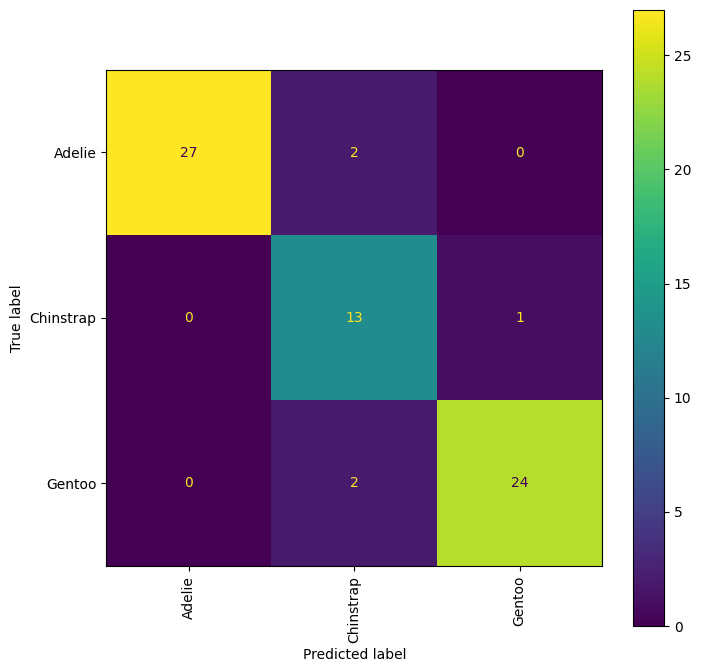

In [48]:
# create and plot confusion matrix
conf_matrix = confusion_matrix(classes_test, classes_predicted)

fig = plt.figure(figsize=(8, 8))
label_names_new = ['Adelie', 'Chinstrap', 'Gentoo']

ConfusionMatrixDisplay(conf_matrix, display_labels=label_names_new).plot(ax=plt.gca())

plt.xticks(rotation=90, ha='center')